Kacper Kaszuba

# Zadanie 2: Optymalne planowanie ścieżki studiów na Informatyce Stosowanej
Masz plik JSON opisujący przedmioty na kierunku "Informatyka Stosowana". Każdy przedmiot zawiera kod, nazwę, liczbę punktów ECTS, kategorię ("obowiązkowy" lub "obieralny") oraz listę kodów przedmiotów wymaganych do realizacji wcześniej (`prerequisites`).


Twoim zadaniem jest napisać program w języku C#/Python, który:


1. Wczyta plik JSON z listą przedmiotów.
2. Ułoży harmonogram realizacji wszystkich przedmiotów w 7 semestrach (oznaczanych 1–7), tak aby:
    - W każdym semestrze suma punktów ECTS wynosiła od **25 do 32**,
    - Łączna liczba punktów ECTS po 7 semestrach wynosiła **dokładnie 210**,
    - Każdy przedmiot został zrealizowany najwcześniej, jak to możliwe, przy zachowaniu wszystkich wymagań wstępnych (`prerequisites`).
    - Przedmioty mogą być realizowane równolegle w tym samym semestrze, jeśli ich wymagania są już spełnione.
3. Wypisze harmonogram w postaci listy semestrów:
    - Dla każdego semestru poda listę przedmiotów i sumę ECTS.
4. W przypadku, gdy nie da się ułożyć poprawnego harmonogramu (np. z powodu sprzecznych wymagań lub braku możliwości spełnienia limitów ECTS), wypisze komunikat: `"Nie można ułożyć poprawnego harmonogramu – sprawdź zależności i limity ECTS."`

## Dodatkowe wymagania:
- Program powinien działać dla dowolnego pliku JSON o tej samej strukturze.
- Przedmioty "obieralne" można wybierać dowolnie, o ile spełnione są powyższe kryteria sumy ECTS i zależności.
- Do oceny przesyłasz jeden plik (.cs lub .py) - kod dla aplikacji konsolowej.

In [32]:
import json
import pandas as pd
import numpy as np
import seaborn as sns

import networkx as nx


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [33]:
# 1. Import danych
with open("przedmioty-inf.json", 'r') as f:
  przedmioty = json.load(f)

przedmioty

[{'code': 'MATH101',
  'name': 'Analiza matematyczna I',
  'ects': 5,
  'prerequisites': [],
  'type': 'obowiązkowy'},
 {'code': 'MATH102',
  'name': 'Analiza matematyczna II',
  'ects': 5,
  'prerequisites': ['MATH101'],
  'type': 'obowiązkowy'},
 {'code': 'MATH201',
  'name': 'Algebra liniowa',
  'ects': 4,
  'prerequisites': [],
  'type': 'obowiązkowy'},
 {'code': 'STAT101',
  'name': 'Rachunek prawdopodobieństwa',
  'ects': 4,
  'prerequisites': ['MATH101'],
  'type': 'obowiązkowy'},
 {'code': 'STAT102',
  'name': 'Statystyka opisowa',
  'ects': 3,
  'prerequisites': ['STAT101'],
  'type': 'obowiązkowy'},
 {'code': 'STAT201',
  'name': 'Statystyka matematyczna',
  'ects': 4,
  'prerequisites': ['STAT102'],
  'type': 'obowiązkowy'},
 {'code': 'MATH301',
  'name': 'Matematyka dyskretna',
  'ects': 5,
  'prerequisites': [],
  'type': 'obowiązkowy'},
 {'code': 'MATH401',
  'name': 'Metody numeryczne',
  'ects': 4,
  'prerequisites': ['MATH102', 'MATH201'],
  'type': 'obowiązkowy'},
 {'

In [34]:
#  Budowa grafu
G = nx.DiGraph()
for sub in przedmioty:
  G.add_node(sub['code'],
             name=sub['name'],
             ects=sub['ects'],
             prerequisites=sub['prerequisites'],
             type_G=sub['type'])
  for s in sub['prerequisites']:
    G.add_edge(s, sub['code'])
print(G)



DiGraph with 61 nodes and 52 edges


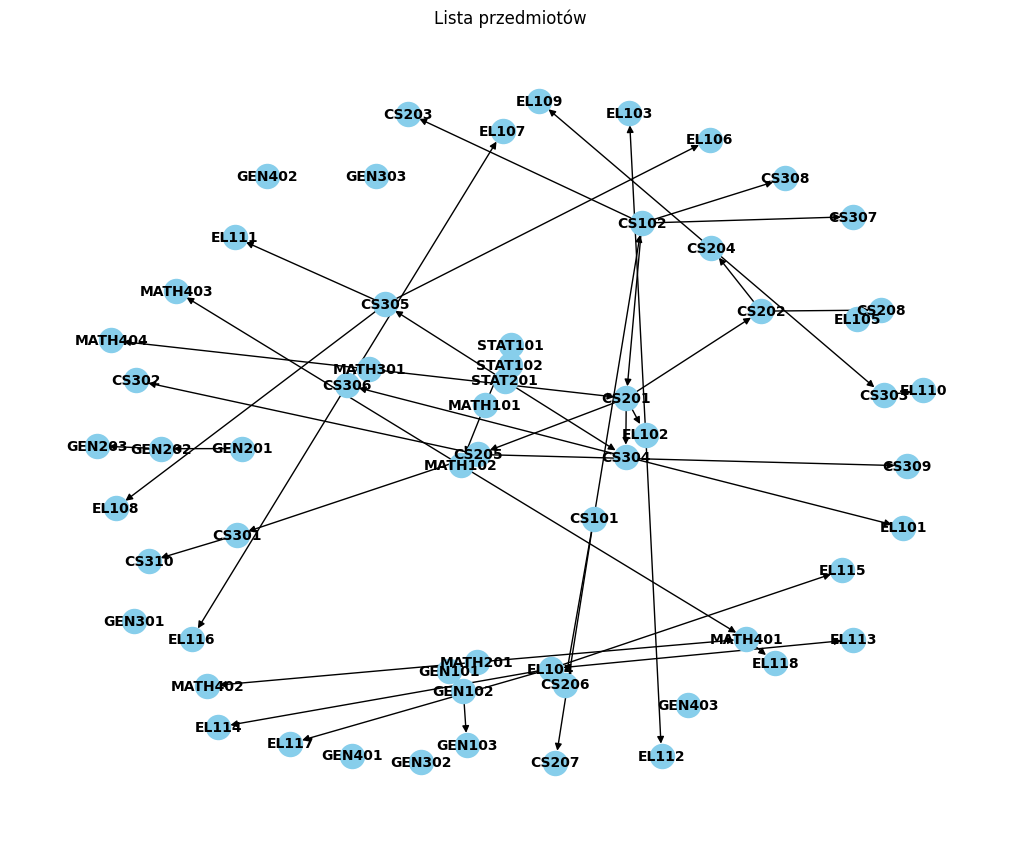

In [35]:
plt.figure(figsize=(10, 8))
nx.draw(G, with_labels=True, node_color='skyblue', font_size=10, font_weight='bold')
plt.title("Lista przedmiotów")
plt.show()

In [36]:
import sys

try:
  graph_top = list(nx.topological_sort(G))
except nx.NetworkXUnfeasible:
  print("Nie można ułożyć poprawnego harmonogramu – sprawdź zależności i limity ECTS.")
  sys.exit()
graph_top

['MATH101',
 'MATH201',
 'MATH301',
 'CS101',
 'GEN101',
 'GEN201',
 'GEN301',
 'GEN302',
 'GEN303',
 'GEN401',
 'GEN402',
 'GEN403',
 'MATH102',
 'STAT101',
 'MATH402',
 'MATH404',
 'CS102',
 'CS206',
 'CS207',
 'GEN102',
 'GEN202',
 'MATH401',
 'MATH403',
 'STAT102',
 'CS201',
 'CS203',
 'CS307',
 'CS308',
 'EL104',
 'GEN103',
 'GEN203',
 'EL118',
 'STAT201',
 'CS202',
 'CS205',
 'EL102',
 'EL113',
 'EL114',
 'EL115',
 'EL117',
 'CS304',
 'CS305',
 'CS204',
 'CS208',
 'CS301',
 'CS302',
 'CS309',
 'EL103',
 'EL112',
 'CS306',
 'EL101',
 'EL106',
 'EL108',
 'EL111',
 'CS303',
 'EL109',
 'EL105',
 'CS310',
 'EL107',
 'EL116',
 'EL110']

In [37]:
# 2. Sprawdzanei danych
# Sprawdzanei sumy ECTS oraz ects dla obowiązowych i nieobowiązkowych

ects = 0
ects_obi = 0
ects_obw = 0
obowiazkowe= []
obieralne= []
for top in graph_top:
  if G.nodes[top]['type_G'] == 'obowiązkowy':
    ects_obw += G.nodes[top]['ects']
    obowiazkowe.append(top)
  elif G.nodes[top]['type_G'] == 'obieralny':
    obieralne.append(top)
    ects_obi += G.nodes[top]['ects']

  ects += G.nodes[top]['ects']

print(f"Suma ECTS: {ects}")

print(f"Ects dla obieralny: {ects_obi}\nEcts dla obowiązkowy: {ects_obw}")

Suma ECTS: 216
Ects dla obieralny: 107
Ects dla obowiązkowy: 109


In [38]:
# 3. Oblcixanie najwcześniejszego semsetru

semestr_min = {}
for node in graph_top:
  preq =  G.nodes[node]['prerequisites']
  if not preq:
    semestr_min[node] = 1
  else:
    semestr_min[node] = max([semestr_min[p] for p in preq]) + 1

semestr_min

{'MATH101': 1,
 'MATH201': 1,
 'MATH301': 1,
 'CS101': 1,
 'GEN101': 1,
 'GEN201': 1,
 'GEN301': 1,
 'GEN302': 1,
 'GEN303': 1,
 'GEN401': 1,
 'GEN402': 1,
 'GEN403': 1,
 'MATH102': 2,
 'STAT101': 2,
 'MATH402': 2,
 'MATH404': 2,
 'CS102': 2,
 'CS206': 2,
 'CS207': 2,
 'GEN102': 2,
 'GEN202': 2,
 'MATH401': 3,
 'MATH403': 3,
 'STAT102': 3,
 'CS201': 3,
 'CS203': 3,
 'CS307': 3,
 'CS308': 3,
 'EL104': 3,
 'GEN103': 3,
 'GEN203': 3,
 'EL118': 4,
 'STAT201': 4,
 'CS202': 4,
 'CS205': 4,
 'EL102': 4,
 'EL113': 4,
 'EL114': 4,
 'EL115': 4,
 'EL117': 4,
 'CS304': 5,
 'CS305': 5,
 'CS204': 5,
 'CS208': 5,
 'CS301': 5,
 'CS302': 5,
 'CS309': 5,
 'EL103': 5,
 'EL112': 5,
 'CS306': 6,
 'EL101': 6,
 'EL106': 6,
 'EL108': 6,
 'EL111': 6,
 'CS303': 6,
 'EL109': 6,
 'EL105': 6,
 'CS310': 6,
 'EL107': 7,
 'EL116': 7,
 'EL110': 7}

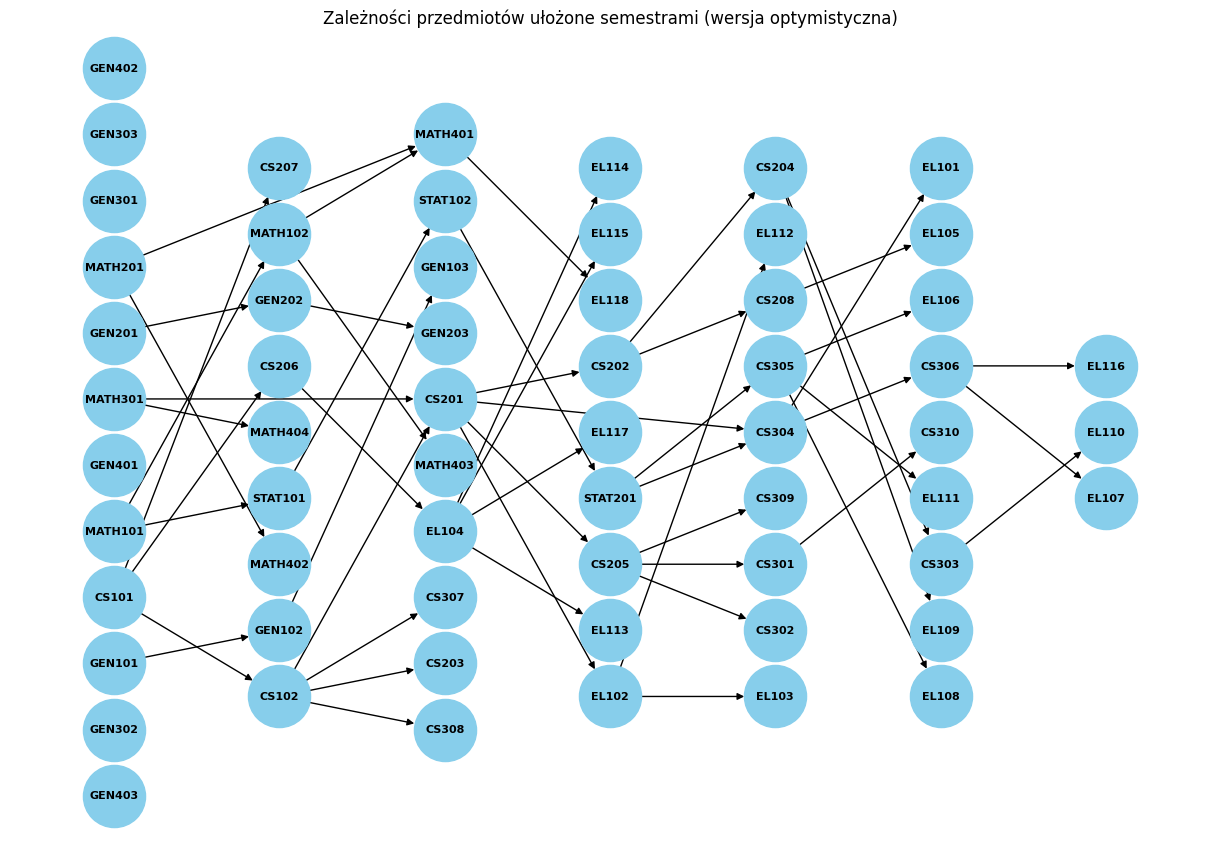

In [39]:
# Wizualizacja za pomocą multipartite_layout
for node, sem in semestr_min.items():
  G.nodes[node]['subset'] = sem

plt.figure(figsize=(12, 8))
pos = nx.multipartite_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=8, font_weight='bold')
plt.title("Zależności przedmiotów ułożone semestrami (wersja optymistyczna)")
plt.show()

In [40]:
# Przydzielenie przedmiotów obowiąskowych

limit_ects = 210
obowiazkowe_posortowane = sorted(obowiazkowe, key=lambda x: semestr_min[x] )

ects_w_sem = {}
harmonogram = {}
zaplanowany_semestr = {}

for i in range(1,8):
  ects_w_sem[i] = 0
  harmonogram[i] = []

for node in obowiazkowe_posortowane:
  preq =  G.nodes[node]['prerequisites']
  if not preq:
    aktualny_sem = semestr_min[node]
  else:
    aktualny_sem = max([zaplanowany_semestr[p] for p in preq]) + 1

  while aktualny_sem <= 7 and ects_w_sem[aktualny_sem] + G.nodes[node]['ects'] > 32:
    aktualny_sem += 1

  if aktualny_sem > 7:
    print("Nie można ułożyć poprawnego harmonogramu – sprawdź zależności i limity ECTS.")
    sys.exit()

  harmonogram[aktualny_sem].append(node)
  ects_w_sem[aktualny_sem] += G.nodes[node]['ects']
  zaplanowany_semestr[node] = aktualny_sem

print(f"ECTS w kazdym semestrzze (stan z samymi obowiazskowymi przedmiotami):\n\t{ects_w_sem}")
print(f"\nHarmonogram:")
display(harmonogram)

print(f"\nObecnie zaplanowany semsetr:")
display(zaplanowany_semestr)


# Przydzielenie przedmiotów dodatkowych
obieralne_posortowane = sorted(obieralne, key=lambda x: semestr_min[x] )
for node in obieralne_posortowane:
  if sum(ects_w_sem.values()) + G.nodes[node]['ects']  > limit_ects:
    continue

  preq =  G.nodes[node]['prerequisites']
  if not preq:
    aktualny_sem = semestr_min[node]
  else:
    aktualny_sem = max([zaplanowany_semestr[p] for p in preq]) + 1

  dostepne_sem = []
  for s in range(aktualny_sem, 8):
    if ects_w_sem[s]  + G.nodes[node]['ects'] <= 32:
      dostepne_sem.append(s)

  if not dostepne_sem:
    continue

  wybrany_sem = min(dostepne_sem, key=lambda p: ects_w_sem[p])

  harmonogram[wybrany_sem].append(node)
  ects_w_sem[wybrany_sem] += G.nodes[node]['ects']
  zaplanowany_semestr[node] = wybrany_sem


print(f"ECTS w kazdym semestrzze:\n\t{ects_w_sem}")
print(f"\nHarmonogram:")
display(harmonogram)

print(f"\nObecnie zaplanowany semsetr:")
display(zaplanowany_semestr)

sum(ects_w_sem.values())

ECTS w kazdym semestrzze (stan z samymi obowiazskowymi przedmiotami):
	{1: 21, 2: 27, 3: 18, 4: 12, 5: 24, 6: 7, 7: 0}

Harmonogram:


{1: ['MATH101', 'MATH201', 'MATH301', 'CS101', 'GEN101', 'GEN201'],
 2: ['MATH102',
  'STAT101',
  'MATH404',
  'CS102',
  'CS206',
  'CS207',
  'GEN102',
  'GEN202'],
 3: ['MATH401', 'STAT102', 'CS201', 'CS203', 'GEN103', 'GEN203'],
 4: ['STAT201', 'CS202', 'CS205'],
 5: ['CS304', 'CS305', 'CS204', 'CS208', 'CS301', 'CS302'],
 6: ['CS303', 'CS310'],
 7: []}


Obecnie zaplanowany semsetr:


{'MATH101': 1,
 'MATH201': 1,
 'MATH301': 1,
 'CS101': 1,
 'GEN101': 1,
 'GEN201': 1,
 'MATH102': 2,
 'STAT101': 2,
 'MATH404': 2,
 'CS102': 2,
 'CS206': 2,
 'CS207': 2,
 'GEN102': 2,
 'GEN202': 2,
 'MATH401': 3,
 'STAT102': 3,
 'CS201': 3,
 'CS203': 3,
 'GEN103': 3,
 'GEN203': 3,
 'STAT201': 4,
 'CS202': 4,
 'CS205': 4,
 'CS304': 5,
 'CS305': 5,
 'CS204': 5,
 'CS208': 5,
 'CS301': 5,
 'CS302': 5,
 'CS303': 6,
 'CS310': 6}

ECTS w kazdym semestrzze:
	{1: 21, 2: 27, 3: 18, 4: 22, 5: 27, 6: 30, 7: 31}

Harmonogram:


{1: ['MATH101', 'MATH201', 'MATH301', 'CS101', 'GEN101', 'GEN201'],
 2: ['MATH102',
  'STAT101',
  'MATH404',
  'CS102',
  'CS206',
  'CS207',
  'GEN102',
  'GEN202'],
 3: ['MATH401', 'STAT102', 'CS201', 'CS203', 'GEN103', 'GEN203'],
 4: ['STAT201', 'CS202', 'CS205', 'CS307', 'CS308', 'EL102'],
 5: ['CS304', 'CS305', 'CS204', 'CS208', 'CS301', 'CS302', 'EL112'],
 6: ['CS303',
  'CS310',
  'GEN401',
  'GEN402',
  'MATH402',
  'EL104',
  'CS309',
  'EL103',
  'CS306'],
 7: ['GEN301',
  'GEN302',
  'GEN303',
  'GEN403',
  'MATH403',
  'EL118',
  'EL113',
  'EL114',
  'EL115']}


Obecnie zaplanowany semsetr:


{'MATH101': 1,
 'MATH201': 1,
 'MATH301': 1,
 'CS101': 1,
 'GEN101': 1,
 'GEN201': 1,
 'MATH102': 2,
 'STAT101': 2,
 'MATH404': 2,
 'CS102': 2,
 'CS206': 2,
 'CS207': 2,
 'GEN102': 2,
 'GEN202': 2,
 'MATH401': 3,
 'STAT102': 3,
 'CS201': 3,
 'CS203': 3,
 'GEN103': 3,
 'GEN203': 3,
 'STAT201': 4,
 'CS202': 4,
 'CS205': 4,
 'CS304': 5,
 'CS305': 5,
 'CS204': 5,
 'CS208': 5,
 'CS301': 5,
 'CS302': 5,
 'CS303': 6,
 'CS310': 6,
 'GEN301': 7,
 'GEN302': 7,
 'GEN303': 7,
 'GEN401': 6,
 'GEN402': 6,
 'GEN403': 7,
 'MATH402': 6,
 'MATH403': 7,
 'CS307': 4,
 'CS308': 4,
 'EL104': 6,
 'EL118': 7,
 'EL102': 4,
 'EL113': 7,
 'EL114': 7,
 'EL115': 7,
 'CS309': 6,
 'EL103': 6,
 'EL112': 5,
 'CS306': 6}

176

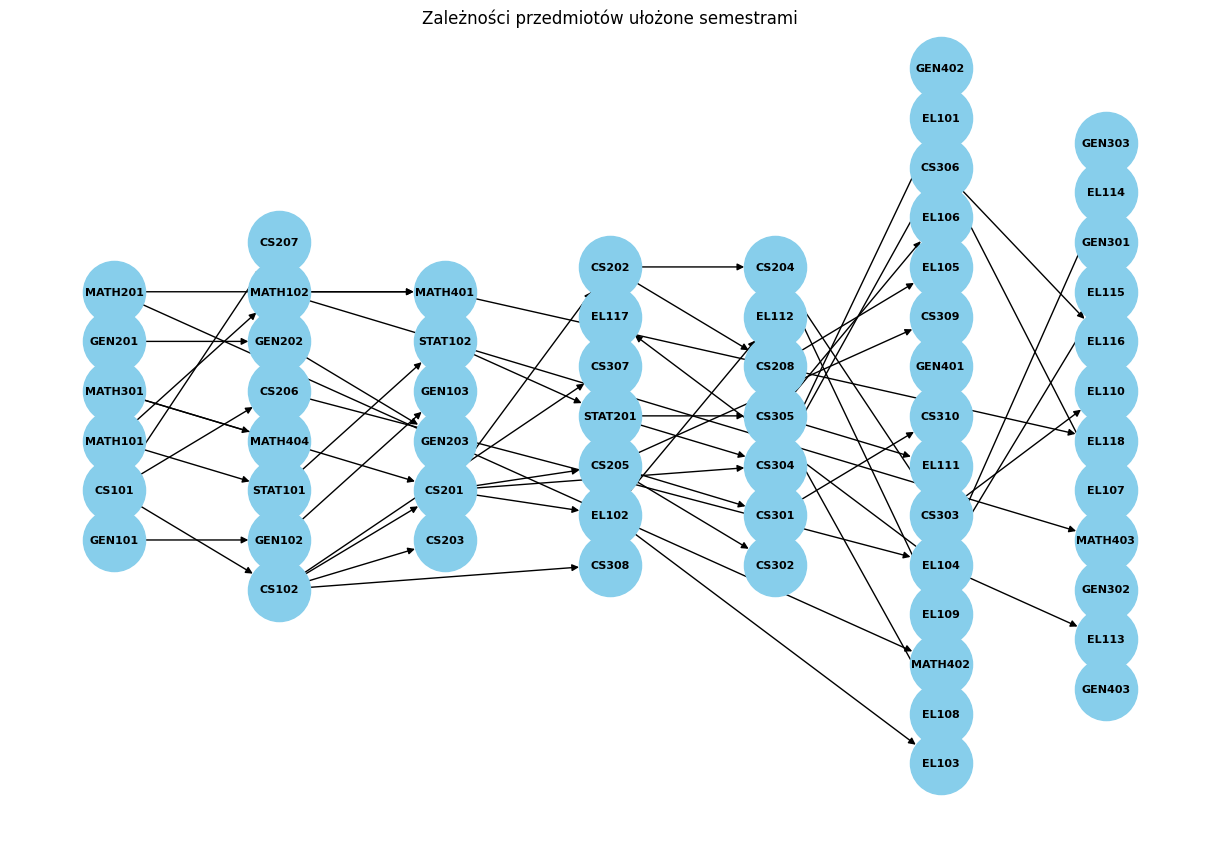

In [41]:
# Wizualizacja za pomocą multipartite_layout
for node, sem in zaplanowany_semestr.items():
  G.nodes[node]['subset'] = sem

plt.figure(figsize=(12, 8))
pos = nx.multipartite_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=8, font_weight='bold')
plt.title("Zależności przedmiotów ułożone semestrami")
plt.show()

Semestr 1 (ECTS: 29): MATH101, MATH201, MATH301, CS101, GEN101, GEN201, GEN403, GEN302, GEN302
Semestr 2 (ECTS: 29): MATH102, STAT101, MATH404, CS102, CS206, CS207, GEN102, GEN202, GEN402
Semestr 3 (ECTS: 29): MATH401, STAT102, CS201, CS203, GEN103, GEN203, GEN401, GEN301, GEN303, CS308
Semestr 4 (ECTS: 32): STAT201, CS202, CS205, CS307, CS308, EL102, GEN402, MATH402, EL104
Semestr 5 (ECTS: 30): CS304, CS305, CS204, CS208, CS301, CS302, EL112, CS307
Semestr 6 (ECTS: 30): CS303, CS310, GEN401, GEN402, MATH402, EL104, CS309, EL103, CS306
Semestr 7 (ECTS: 31): GEN301, GEN302, GEN303, GEN403, MATH403, EL118, EL113, EL114, EL115
Suma ECTS: 210


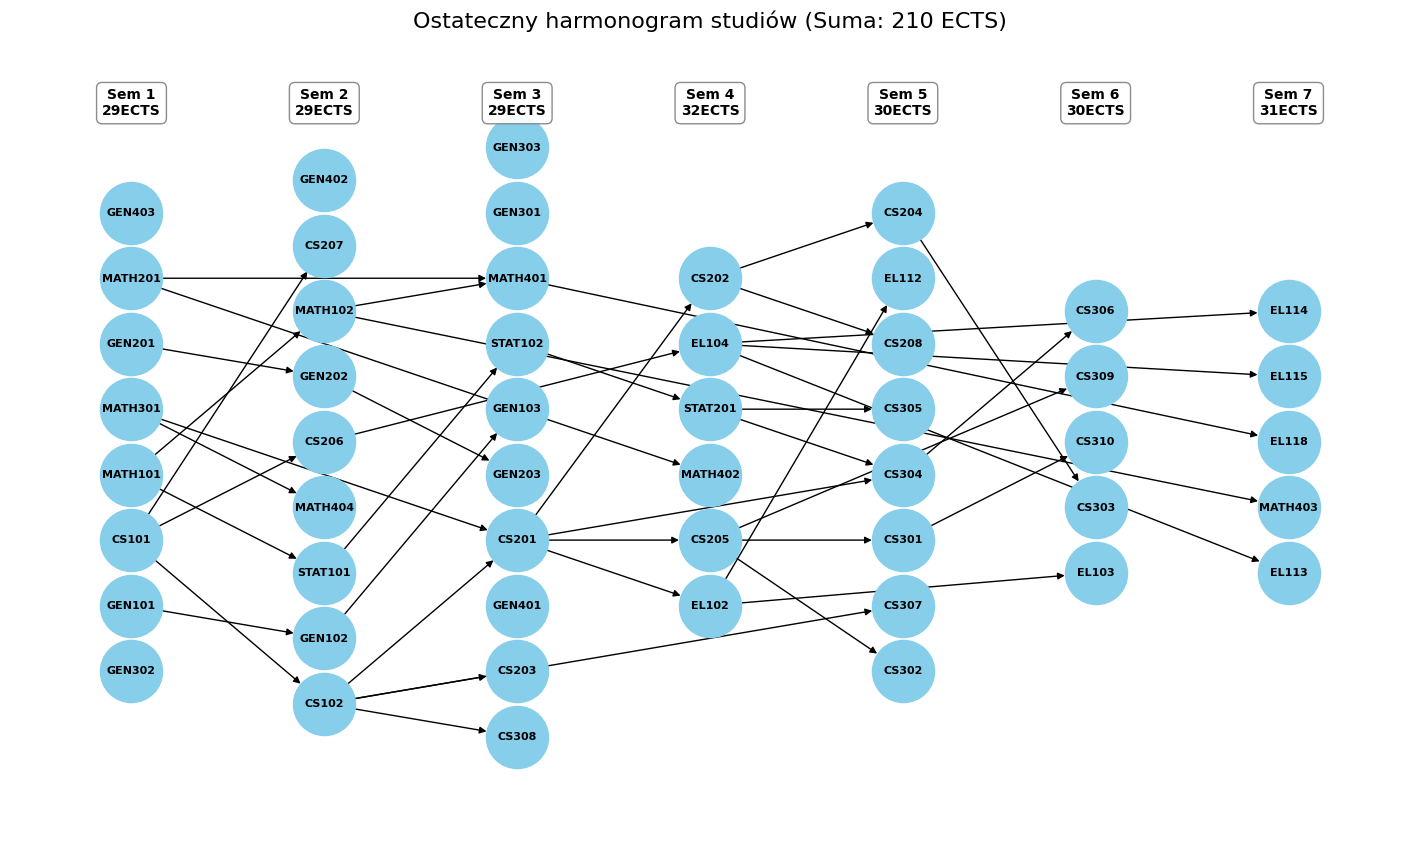

In [43]:
import random
import copy

# Próby losowe
backup_harmonogram = copy.deepcopy(harmonogram)
backup_ects = copy.deepcopy(ects_w_sem)
backup_zaplanowany = copy.deepcopy(zaplanowany_semestr)

sukces = False

for  proba in range(100):
  harmonogram = copy.deepcopy(backup_harmonogram)
  ects_w_sem = copy.deepcopy(backup_ects)
  zaplanowany_semestr = copy.deepcopy(backup_zaplanowany)

  obieralne_posortowane = sorted(obieralne, key=lambda x:semestr_min[x] + random.random())

  for node in obieralne_posortowane:

    if sum(ects_w_sem.values()) +  G.nodes[node]['ects'] > limit_ects:
      continue

    preq = list(G.predecessors(node))

    if not all(p in zaplanowany_semestr for p in preq):
      continue

    if not preq:
      aktualny_sem = semestr_min[node]
    else:
      aktualny_sem = max([zaplanowany_semestr[p] for p in preq]) + 1

    dostepne_sem  = []
    for s in range(aktualny_sem, 8):
      if ects_w_sem[s] + G.nodes[node]['ects'] <= 32:
        dostepne_sem.append(s)
    if not dostepne_sem:
      continue

    wybrany_sem = min(dostepne_sem, key=lambda s: ects_w_sem[s])

    harmonogram[wybrany_sem].append(node)
    ects_w_sem[wybrany_sem] += G.nodes[node]['ects']
    zaplanowany_semestr[node] = wybrany_sem

  if sum(ects_w_sem.values()) == limit_ects and all(ects >= 25 for ects  in ects_w_sem.values()):
    sukces = True
    break

if not sukces:
  print(f"Nie można ułożyć poprawnego harmonogramu Sprawćzależności i limity ECTS")
else:
  for sem in range(1,8):
    przedmioty_str = ", ".join(harmonogram[sem])
    print(f"Semestr {sem} (ECTS: {ects_w_sem[sem]}): {przedmioty_str}")
  print(f"Suma ECTS: {sum(ects_w_sem.values())}")

  # Rysowanie
  G_zrealizowane = G.subgraph(list(zaplanowany_semestr.keys()))

  for node, sem in zaplanowany_semestr.items():
      G_zrealizowane.nodes[node]['subset'] = sem

  plt.figure(figsize=(14, 8))
  pos = nx.multipartite_layout(G_zrealizowane)
  nx.draw(G_zrealizowane, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=8, font_weight='bold')

  semestr_x = {}
  for node, (x, y) in pos.items():
    sem = G_zrealizowane.nodes[node]['subset']
    if sem not in semestr_x:
      semestr_x[sem] = x

  max_y = max( y for x, y in pos.values())

  for sem, x in semestr_x.items():
    punkty = ects_w_sem[sem]
    plt.text(x,max_y + 0.15, f'Sem {sem}\n{punkty}ECTS',
            ha='center', va='center', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9))

  plt.margins(y=0.15)
  plt.title(f"Ostateczny harmonogram studiów (Suma: {sum(ects_w_sem.values())} ECTS)", fontsize=16, pad=20)
  plt.show()

